#  Análise Exploratória de Dados - Análise Multivariada: The Movies Dataset

In [1]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..')))

# Importação de Bibliotecas e Módulos
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Módulos customizados da pasta src/
import src.io.data_loader as dl
import src.utils.data_quality as dq
import src.utils.metrics as mt
import src.view.plots as graf
import src.view.tables as tb
import src.utils.reshaping as rsh

---

## Carregando Dados

In [2]:
caminho = '../data/interim/movies/movies_enriched.parquet'
df_movies = dl.load_data(file_path=caminho, tipo_arquivo='parquet')

Dados Parquet carregados! Formato: (41091, 22)


--- 
## Mitigação Temporária De Erros De Preenchimento

* Filtrando orçamentos e faturamentos irreais (**< 5 mil**) para evitar distorções severas nas análises relacionais e multivariadas.

In [3]:
filtro_valores_reais = (df_movies['budget'] >= 5_000) & (df_movies['revenue'] >= 5_000)

df_movies = df_movies[filtro_valores_reais].copy()

---
## Matriz de Dispersão de Valores Numéricos

Nota: Exibindo amostra aleatória de 3000 registros para performance.


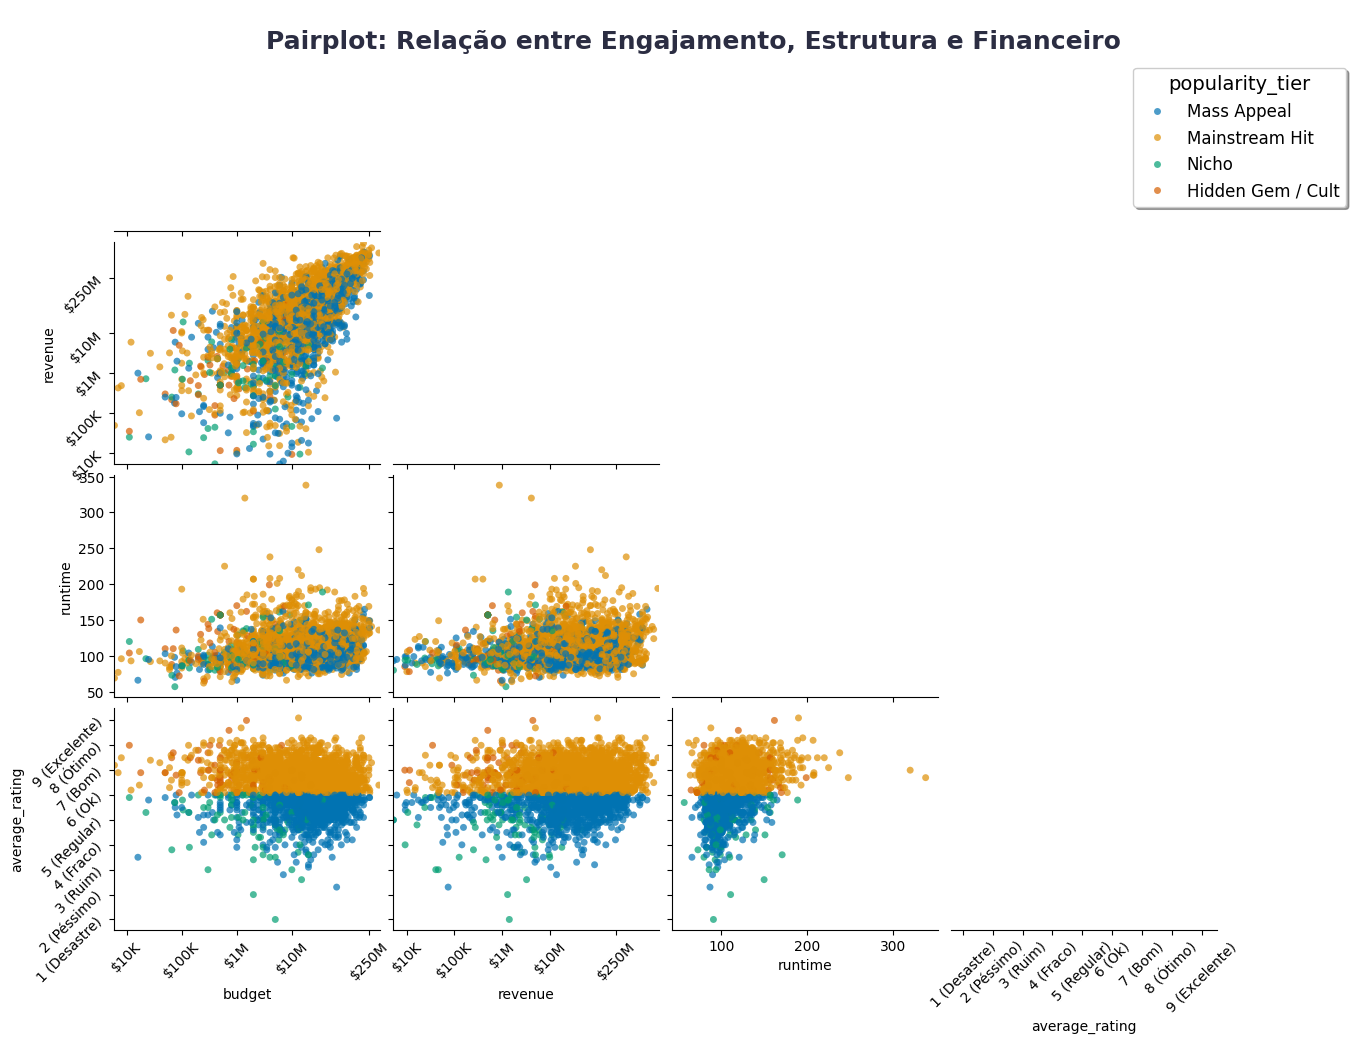

In [4]:
regras_de_escala = {
    'budget': {'tipo_dado': 'moeda', 'usar_log': True},
    'revenue': {'tipo_dado': 'moeda', 'usar_log': True},
    'runtime' : {'tipo_dado': 'hora_12'},
    'average_rating' : {'tipo_dado': 'nota_10'}
}

graf.grafico_pairplot_numericos(
    df_plot=df_movies,
    cols_focadas=[
        'budget', 
        'revenue', 
        'runtime', 
        'average_rating'
    ],
    col_log=regras_de_escala,        
    coluna_hue='popularity_tier',  
    altura_painel=2.5,
    titulo="Pairplot: Relação entre Engajamento, Estrutura e Financeiro"
)

## Conclusão Matriz de Dispersão 

###  Principais Conclusões:

* **O Motor Econômico (Orçamento ➔ Bilheteria):** Como esperado, existe uma correlação linear positiva robusta entre `budget` e `revenue`. O mercado opera em um ciclo lógico de escala: investimentos massivos financiam produções de maior escopo, que por consequência recebem campanhas de marketing agressivas, resultando em retornos bilionários. Essa dinâmica é dominada pelas categorias **Mass Appeal** e **Mainstream**.

* **A Estrutura do Escopo (`runtime` ➔ `budget`):** Filmes mais longos exigem maior orçamento devido aos custos óbvios de produção (diárias de elenco, cenografia, equipe técnica e pós-produção). No entanto, a distribuição contra a avaliação (`average_rating`) revela uma **"Zona de Ouro" entre 100 e 150 minutos**, onde se concentram as maiores notas do ecossistema. Filmes fora desse intervalo tendem a ser punidos por superficialidade (curtos demais) ou ritmo cansativo (longos demais).

* **O Colchão de Segurança da Crítica:** A análise de `revenue` vs. `average_rating` mostra que o sucesso comercial altera a variância das notas. Enquanto produções de baixo orçamento sofrem com notas imprevisíveis (extremos de fracasso ou aclamação Cult), as superproduções de alta bilheteria são empurradas para uma zona de convergência estável (entre 6.0 e 8.0). O alcance de massa padroniza a percepção do público.

**Insight Final:** O dinheiro tem o poder de ditar o tamanho físico do filme e garantir o seu retorno financeiro através do marketing de massa, mas a aclamação crítica permanece amplamente soberana e subjetiva. O grupo **Mainstream** representa o ápice da eficiência da indústria: produções que justificam seus orçamentos colossais e tempos de tela longos sem sacrificar a experiência e o respeito do espectador.

---
## Gráfico de Bolhas

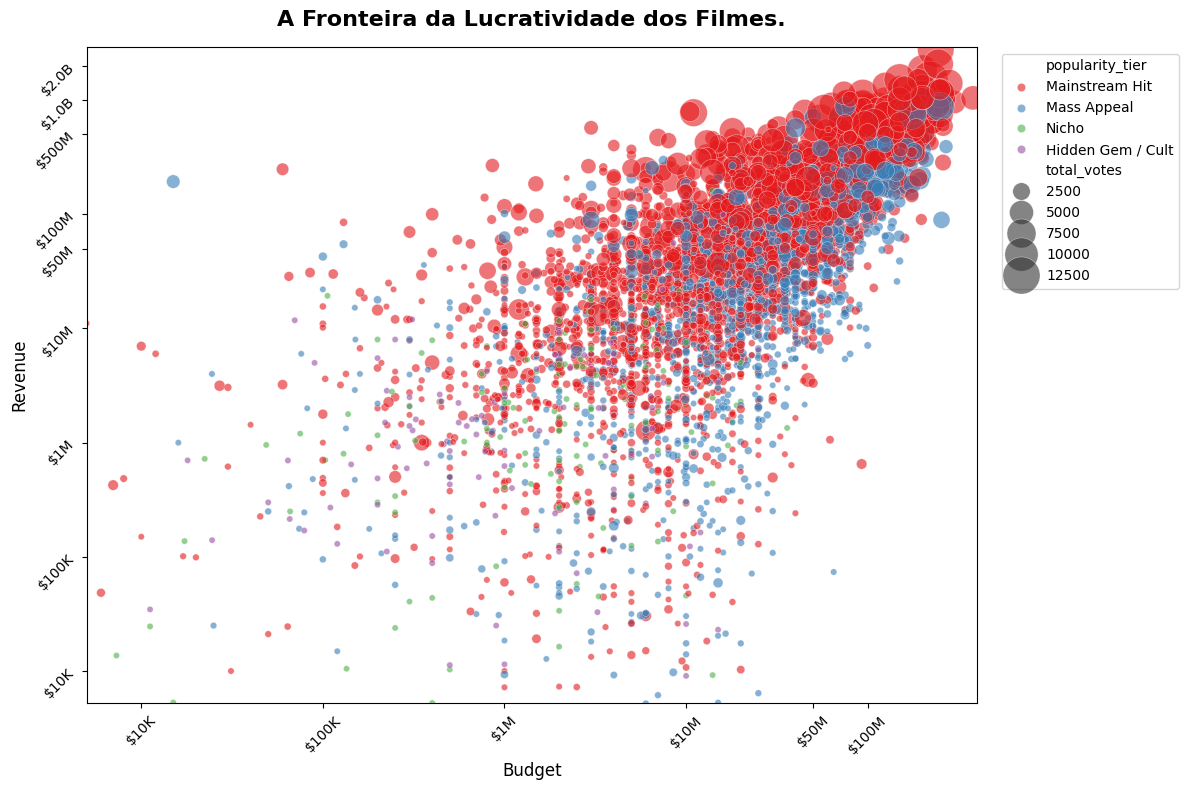

In [5]:
conf_x = {'col': 'budget', 'tipo_dado': 'moeda', 'usar_log': True}
conf_y = {'col': 'revenue', 'tipo_dado': 'moeda', 'usar_log': True}

graf.grafico_bubble_multivariado(
    df_plot=df_movies,
    x_col_dict=conf_x,
    y_col_dict=conf_y,
    size_col='total_votes',
    hue_col='popularity_tier',
    titulo="A Fronteira da Lucratividade dos Filmes."
)

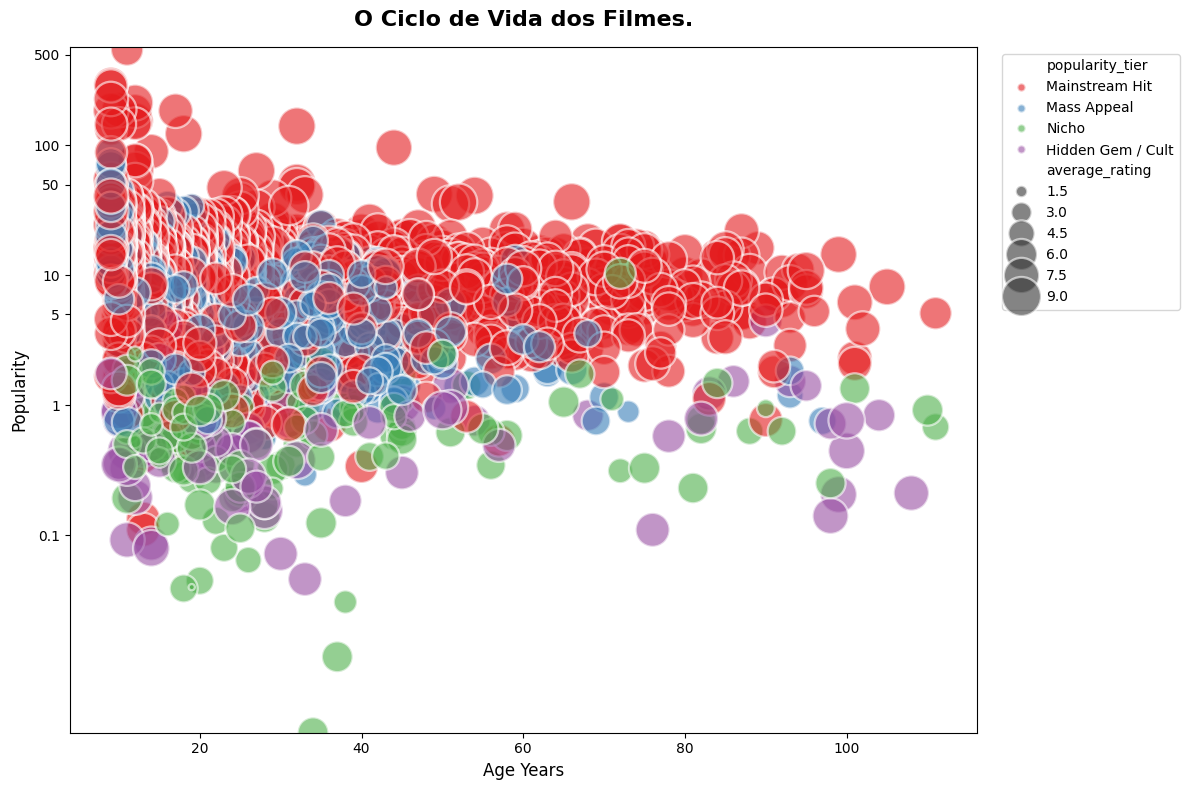

In [6]:
conf_x = {'col': 'age_years', 'usar_log': False}
conf_y = {'col': 'popularity', 'tipo_dado': 'popularidade', 'usar_log': True}

graf.grafico_bubble_multivariado(
    df_plot=df_movies,
    x_col_dict=conf_x,
    y_col_dict=conf_y,
    size_col='average_rating',
    hue_col='popularity_tier',
    titulo="O Ciclo de Vida dos Filmes."
)

# Conclusão Bubble Charts

###  Principais Conclusões:

* **A Fronteira da Lucratividade (Orçamento vs. Bilheteria):** O cruzamento financeiro valida a hierarquia de investimento de Hollywood. 
  * **Mainstream Hit:** Torna-se o dominador absoluto do extremo superior direito. É a engrenagem de maior escalabilidade da indústria, onde orçamentos massivos são convertidos de forma previsível em bilheterias bilionárias.
  * **Mass Appeal:** Senta-se logo abaixo do topo, entregando altíssimo engajamento (volume de votos), mas com um teto de faturamento mais comercialmente limitado que os grandes blocos Mainstream.
  * **Cult e Nicho:** Operam na base de baixo custo, mas frequentemente demonstram picos verticais de faturamento. Apresentam um risco financeiro mínimo e uma eficiência de ROI (Retorno sobre Investimento) percentual altamente competitiva.

* **O Ciclo de Vida e a Resiliência Temporal (Idade vs. Popularidade):** O tempo atua como o filtro definitivo de relevância para a indústria cinematográfica.
  * **O Declínio do Hype (Mass Appeal/Mainstream):** Ambas as categorias sofrem um decaimento severo de popularidade à medida que envelhecem. O Mass Appeal, especificamente, concentra-se quase em sua totalidade nos anos recentes, desaparecendo do radar do público geral com o passar das décadas.
  * **A Estabilidade da Cauda Longa (Cult/Nicho):** Desenham uma faixa horizontal contínua e imutável que atravessa gerações. Eles mantêm sua base de popularidade estável por mais de 80 anos, agindo como o catálogo de segurança perpétua dos estúdios.
  * **O Vale do Esquecimento:** Identifica-se uma janela crítica entre os 30 e 60 anos de idade da obra onde ocorre uma severa bifurcação: produções de Nicho que não retêm valor histórico sofrem um colapso completo de popularidade atual, acumulando-se na base zero do gráfico.

**Insight Final:** Hollywood sobrevive da dualidade exposta nestes gráficos. O **Mainstream** e o **Mass Appeal** financiam a engrenagem no curto prazo com injeções massivas de capital e retornos rápidos baseados em campanhas agressivas de marketing. Contudo, o verdadeiro patrimônio histórico e a receita perpétua e previsível de longo prazo residem no catálogo **Cult**, cuja popularidade desafia o envelhecimento e mantém o interesse do público ativo décadas após sua distribuição original.

---
## Gráfico de Coodenadas Paralelas

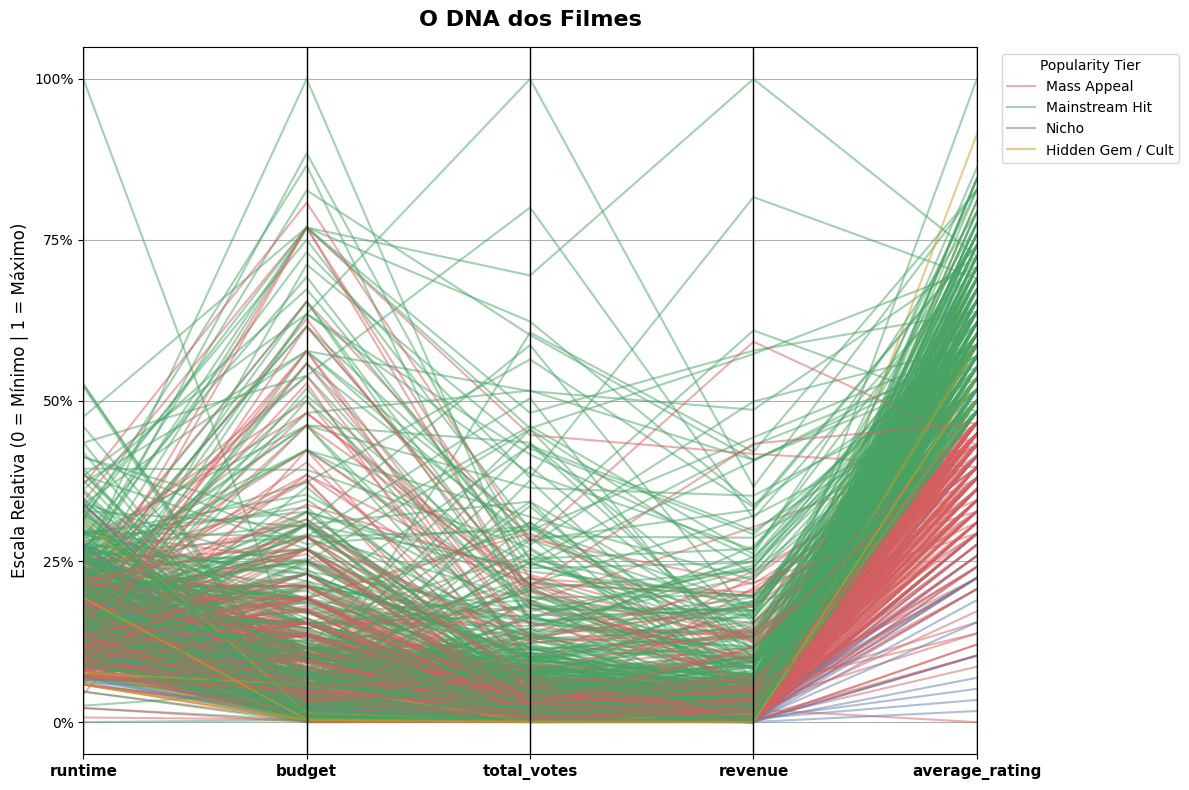

In [7]:
minha_paleta = ['#D65F5F', '#48A365', '#5E81AC', '#D79921']
graf.grafico_coordenadas_paralelas(
    df_plot=df_movies,
    colunas_jornada=['runtime', 'budget', 'total_votes', 'revenue', 'average_rating'],
    coluna_categoria='popularity_tier',
    titulo="O DNA dos Filmes",
    palette=minha_paleta, 
    amostra=800     
)

In [8]:
graf.grafico_coordenadas_paralelas_interativo(
    df_plot=df_movies,
    colunas_jornada=['runtime', 'budget', 'total_votes', 'revenue', 'average_rating'],
    coluna_categoria='popularity_tier',
    titulo="O DNA dos Filmes",
)

# Conclusão Gráfico de Coordenadas Parlelas

### Conclusões Interconectadas da Jornada:

* **O Paradoxo do Orçamento (Dinheiro vs. Qualidade):** Como já havíamos reparado no **Pairplot**, o investimento financeiro não é um preditor direto de qualidade. Nas Coordenadas Paralelas, isso fica evidente: linhas de alto orçamento (`budget`) ramificam-se tanto para notas excelentes quanto para notas medianas na entrega final (`average_rating`). Em contrapartida, as linhas do grupo **Cult** provam que é possível nascer na base do orçamento e escalar o eixo até o topo da aclamação crítica.

* **O Combo do Sucesso Comercial (Popularidade + Receita):** Validando o que observamos no **Gráfico de Bolhas** (onde as maiores bolhas de votos dominavam o topo do eixo de faturamento), as Coordenadas Paralelas mostram que `total_votes` e `revenue` caminham de mãos dadas. As linhas sobem e descem quase em paralelo nesses dois eixos, provando que o engajamento do público (vontade de avaliar) é o combustível direto do faturamento das salas de cinema.

* **O Mito da Duração (A Desmistificação do Runtime):** Diferente da primeira impressão no **Pairplot** — onde parecia haver uma "zona de ouro" para as notas —, o Gráfico de Coordenadas Paralelas revela uma enorme sobreposição de linhas no eixo `runtime`. Isso prova que a duração do filme é uma característica estrutural secundária: todas as categorias (do Nicho ao Mass Appeal) transitam por durações longas e curtas sem que isso dite o sucesso ou o fracasso da obra.

* **O Perfil Supremo do Mainstream Hit:** Este gráfico consolida o papel de "Santo Graal" que atribuímos ao **Mainstream** no **Gráfico de Bolhas**. O perfil visual de suas linhas é único e ultra-característico: elas mantêm-se firmes no topo em `total_votes`, sobem em `revenue` e terminam com notas consistentemente elevadas em `average_rating`. É a única categoria que quebra a regra do *trade-off* e entrega volume com qualidade de forma previsível.

---

### Encerramento da Análise Multivariada de Entretenimento

Ao final desta jornada exploratória, consolidamos uma inteligência de mercado idêntica tanto para os Livros (Goodreads) quanto para os Filmes (TMDB):

O mercado de entretenimento é sustentado por uma engrenagem de duas forças complementares. De um lado, o **Mass Appeal** atua como o motor de tração e fluxo de caixa rápido através do *hype* e do marketing, aceitando o preço de uma recepção crítica mais baixa. Do outro, o **Mainstream** e o **Cult** funcionam como os verdadeiros pilares de retenção de valor, consistência de marca e imortalidade do catálogo da indústria através das décadas.